# Import Packages

In [1]:
import numpy as np # numpy, for mathematics and performing vector operations
import pandas as pd # pandas, for importing data and working with dataframes
from sklearn.preprocessing import OneHotEncoder # scikit-learn, for one-hot encoding categorical features for modelling
from xgboost import XGBClassifier # xgboost, for classification model
from causalml.propensity import ElasticNetPropensityModel # causalml, for propensity score estimation
from causalml.inference.meta import BaseSClassifier # causalml, for treatment effect estimation
from causalml.metrics.sensitivity import Sensitivity # causalml, for sensitivity testing
import matplotlib # matplotlib, for plots
import matplotlib.pyplot as plt # matplotlib, for plots

# Import Data

In [2]:
# import the NHIS 2024 public use dataset
data = pd.read_csv('adult24.csv')
# preview data
#data.head(3)

# Pre-Process Data (Cleaning and Feature Engineering)

In [4]:
# function for defining the binary medical care variable
def BinaryCare(frame):
    '''Defines the binary medical care variable for analyses (=1 for did not get medical care due to cost, =0 for otherwise)'''
    
    # "needed medical care, but DID NOT GET IT because of the cost"
    BinaryCare = np.nan # missing by default
    # if No
    if (frame.MEDNG12M_A == 2):
        BinaryCare = 0
    # if Yes
    elif (frame.MEDNG12M_A == 1):
        BinaryCare = 1
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.MEDNG12M_A in [7, 8, 9]):
        BinaryCare = np.nan
    
    return BinaryCare

# function for defining the insurance coverage variable
def NotInsured(frame):
    '''Defines the insurance coverage variable for analyses (=1 for no coverage, =0 for coverage)'''
    
    # "Coverage status as used in Health United States...
    # Adults are considered uninsured if they did not have private health insurance,
    # Medicare, Medicaid, State Children's Health Insurance Program (CHIP), a state-
    # sponsored health plan, other government programs, or military health plan
    # (includes TRICARE, VA, and CHAMP-VA) at the time of interview. This definition
    # of uninsured matches that used in Health United States."
    NotInsured = np.nan # missing by default
    # if Covered, then has insurance(=0)
    if (frame.NOTCOV_A == 2):
        NotInsured = 0
    # if Not covered, then no insurance(=1)
    elif (frame.NOTCOV_A == 1):
        NotInsured = 1
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.NOTCOV_A in [7, 8, 9]):
        NotInsured = np.nan
    
    return NotInsured

# function for defining the age variable
def Age(frame):
    '''Defines the age variable for analyses (numerical, 18-85+ [top-coded])'''
    
    # Age of sample adult
    Age = np.nan # missing by default
    # if within expected range, keep
    if (frame.AGEP_A >= 18 and frame.AGEP_A <= 85):
        Age = frame.AGEP_A
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.NOTCOV_A in [97, 98, 99]):
        Age = np.nan
    
    return Age

# function for defining the race variable
def Race(frame):
    '''Defines the race variable for analyses (=1 for Hispanic, =2 for Non-Hispanic [NH] White, =3 for NH Black, =4 for Other Race)'''
    
    # Race of sample adult
    Race = np.nan # missing by default
    # if Hispanic
    if (frame.HISPALLP_A == 1):
        Race = 1
    # if NH White
    elif (frame.HISPALLP_A == 2):
        Race = 2
    # if NH Black
    elif (frame.HISPALLP_A == 3):
        Race = 3
    # if NH Asian, NH AIAN, or Other single and multiple races
    elif (frame.HISPALLP_A in [4, 5, 6, 7]):
        Race = 4
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.HISPALLP_A in [97, 98, 99]):
        Race = np.nan
    
    return Race

# function for defining the sex variable
def Sex(frame):
    '''Defines the sex variable for analyses (=1 for Female, =2 for Male)'''
    
    # Sex of sample adult
    Sex = np.nan # missing by default
    # if Female
    if (frame.SEX_A == 2):
        Sex = 1
    # if Male
    elif (frame.SEX_A == 1):
        Sex = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.SEX_A in [7, 8, 9]):
        Sex = np.nan
    
    return Sex

# function for defining the physical activity variable
def PhysicalActivity(frame):
    '''Defines the moderate physical activity variable for analyses (numerical, 0-28 times per week)'''
    
    # Physical activity frequency of sample adult
    PhysicalActivity = np.nan # missing by default
    # if within expected range, keep
    if (frame.MODFREQW_A >= 0 and frame.MODFREQW_A <= 28):
        PhysicalActivity = frame.MODFREQW_A
    # if Never or Unable to do this type of activity
    elif (frame.MODFREQW_A in [94, 96]):
        PhysicalActivity = 0
    # if Extreme value, Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.MODFREQW_A in [95, 97, 98, 99]):
        PhysicalActivity = np.nan
    
    return PhysicalActivity

# function for defining the education variable
def Education(frame):
    '''Defines the education variable for analyses (=1 for <High School, =2 for High School [or equivalent], =3 for >High School)'''
    
    # Education of sample adult
    Education = np.nan # missing by default
    # if Never attended/kindergarten only, Grade 1-11, or 12th grade, no diploma
    if (frame.EDUCP_A in [0, 1, 2]):
        Education = 1
    # if GED or equivalent or High School Graduate
    elif (frame.EDUCP_A in [3, 4]):
        Education = 2
    # if Some college, no degree, Associate degree: occupational, technical, or vocational program,
    # Associate degree: academic program, Bachelor's degree (Example: BA, AB, BS, BBA), 
    # Master's degree (Example: MA, MS, MEng, MEd, MBA), or 
    # Professional School or Doctoral degree (Example: MD, DDS, DVM, JD, PhD, EdD)
    elif (frame.EDUCP_A in [5, 6, 7, 8, 9, 10]):
        Education = 3
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.EDUCP_A in [97, 98, 99]):
        Education = np.nan
    
    return Education

# function for defining the disability variable
def Disability(frame):
    '''Defines the disability variable for analyses (=1 for disabled, =2 for not disabled)'''
    
    # Disability of sample adult
    Disability = np.nan # missing by default
    # if disabled
    if (frame.DISAB3_A == 1):
        Disability = 1
    # if not disabled
    elif (frame.DISAB3_A == 2):
        Disability = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.DISAB3_A in [7, 8, 9]):
        Disability = np.nan
    
    return Disability

# function for defining the urban-rural classification variable
def UrbanRural(frame):
    '''Defines the urban-rural classification variable for analyses (=1 for large central metro, =2 for large fringe metro, =3 for medium and small metro, =4 for nonmetropolitan)'''
    
    # Urban-rural classification of sample adult
    UrbanRural = np.nan # missing by default
    # if Large central metro
    if (frame.URBRRL23 == 1):
        UrbanRural = 1
    # if Large fringe metro
    elif (frame.URBRRL23 == 2):
        UrbanRural = 2
    # if Medium and small metro
    elif (frame.URBRRL23 == 3):
        UrbanRural = 3
    # if Nonmetropolitan
    elif (frame.URBRRL23 == 4):
        UrbanRural = 4
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.URBRRL23 in [7, 8, 9]):
        UrbanRural = np.nan
    
    return UrbanRural

# function for defining the region variable
def Region(frame):
    '''Defines the region variable for analyses (=1 for Northeast, =2 for Midwest, =3 for South, =4 for West)'''
    
    # Region of sample adult
    Region = np.nan # missing by default
    # if Northeast
    if (frame.REGION == 1):
        Region = 1
    # if Midwest
    elif (frame.REGION == 2):
        Region = 2
    # if South
    elif (frame.REGION == 3):
        Region = 3
    # if West
    elif (frame.REGION == 4):
        Region = 4
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.REGION in [7, 8, 9]):
        Region = np.nan
    
    return Region

# function for defining the sexual orientation variable
def SexualOrientation(frame):
    '''Defines the sexual orientation variable for analyses (=1 for Straight, =2 for Gay/Lesbian/Bisexual, =3 for Other)'''
    
    # Sexual orientation of sample adult
    SexualOrientation = np.nan # missing by default
    # if Straight
    if (frame.ORIENT_A == 2):
        SexualOrientation = 1
    # if "GayLesbian" or "Bisexual"
    elif (frame.ORIENT_A in [1, 3]):
        SexualOrientation = 2
    # if "Something else" or "I don't know the answer"
    elif (frame.ORIENT_A in [4, 5]):
        SexualOrientation = 3
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.ORIENT_A in [7, 8, 9]):
        SexualOrientation = np.nan
    
    return SexualOrientation

# function for defining the current smoking status variable
def CurrentSmoking(frame):
    '''Defines the current smoking status variable for analyses (=1 for current smoking [100+ lifetime cigarettes and "now" smokes "every day" or "some days"],
       =2 for not current smoking [<100 lifetime cigarettes OR 100+ lifetime cigarettes and "now" smokes "not at all"])'''
    
    # Current smoking status of sample adult
    CurrentSmoking = np.nan # missing by default
    # if current smoking
    if (frame.SMKEV_A == 1 and (frame.SMKNOW_A in [1, 2])):
        CurrentSmoking = 1
    # if not current smoking
    elif ((frame.SMKEV_A == 2) or (frame.SMKEV_A == 1 and frame.SMKNOW_A == 3)):
        CurrentSmoking = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.SMKEV_A in [7, 8, 9] or frame.SMKNOW_A in [7, 8, 9]):
        CurrentSmoking = np.nan
    # if missing any of the component variables, set to numpy missing
    if (frame.SMKEV_A == np.nan or frame.SMKNOW_A == np.nan):
        CurrentSmoking = np.nan
    
    return CurrentSmoking

# function for defining the family income variable
def FamilyIncome(frame):
    '''Defines the family income variable for analyses as a function of the poverty threshold (numerical, 0-11+ [top-coded])'''
    
    # Family income of sample adult
    FamilyIncome = np.nan # missing by default
    # if within expected range, keep
    if (frame.POVRATTC_A >= 0 and frame.POVRATTC_A <= 11):
        FamilyIncome = frame.POVRATTC_A
    # if not within expected range, set to missing
    else:
        FamilyIncome = np.nan
    
    return FamilyIncome

# function for defining the general health variable
def GeneralHealth(frame):
    '''Defines the general health status variable for analyses (=1 for Excellent, Very Good, or Good, =2 for Fair, =3 for Poor)'''
    
    # general health status of sample adult
    GeneralHealth = np.nan # missing by default
    # if excellent, very good, or good
    if (frame.PHSTAT_A in [1, 2, 3]):
        GeneralHealth = 1
    # if fair
    elif (frame.PHSTAT_A == 4):
        GeneralHealth = 2
    # if poor
    elif (frame.PHSTAT_A == 5):
        GeneralHealth = 3
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.PHSTAT_A in [7, 8, 9]):
        GeneralHealth = np.nan
    
    return GeneralHealth

# function for defining the BMI variable
def BMI(frame):
    '''Defines the BMI variable for analyses (=1 for underweight, =2 for healthy weight, =3 for overweight, =4 for obese)'''
    
    # BMI of sample adult
    BMI = np.nan # missing by default
    # if underweight
    if (frame.BMICAT_A == 1):
        BMI = 1
    # if healthy weight
    elif (frame.BMICAT_A == 2):
        BMI = 2
    # if overweight
    elif (frame.BMICAT_A == 3):
        BMI = 3
    # if obese
    elif (frame.BMICAT_A == 4):
        BMI = 4
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.BMICAT_A in [7, 8, 9]):
        BMI = np.nan
    
    return BMI

# function for defining the cancer variable
def Cancer(frame):
    '''Defines the cancer variable for analyses (=1 for ever had cancer, =2 for never had cancer)'''
    
    # Cancer history of sample adult
    Cancer = np.nan # missing by default
    # if ever had cancer
    if (frame.CANEV_A == 1):
        Cancer = 1
    # if never had cancer
    elif (frame.CANEV_A == 2):
        Cancer = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.CANEV_A in [7, 8, 9]):
        Cancer = np.nan
    
    return Cancer

# function for defining the chronic condition status variable
def Chronic(frame):
    '''Defines the chronic condition status variable for analyses (=1 for ever had a chronic condition, =2 for never had a chronic condition)'''
    
    # COPD status of sample adult
    COPD = np.nan # missing by default
    # if ever had COPD
    if (frame.COPDEV_A == 1):
        COPD = 1
    # if never had COPD
    elif (frame.COPDEV_A == 2):
        COPD = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.COPDEV_A in [7, 8, 9]):
        COPD = np.nan

    # Arthritis status of sample adult
    Arthritis = np.nan # missing by default
    # if ever had arthritis
    if (frame.ARTHEV_A == 1):
        Arthritis = 1
    # if never had arthritis
    elif (frame.ARTHEV_A == 2):
        Arthritis = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.ARTHEV_A in [7, 8, 9]):
        Arthritis = np.nan
    
    # Dementia status of sample adult
    Dementia = np.nan # missing by default
    # if ever had dementia
    if (frame.DEMENEV_A == 1):
        Dementia = 1
    # if never had dementia
    elif (frame.DEMENEV_A == 2):
        Dementia = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.DEMENEV_A in [7, 8, 9]):
        Dementia = np.nan

    # Anxiety status of sample adult
    Anxiety = np.nan # missing by default
    # if ever had anxiety
    if (frame.ANXEV_A == 1):
        Anxiety = 1
    # if never had anxiety
    elif (frame.ANXEV_A == 2):
        Anxiety = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.ANXEV_A in [7, 8, 9]):
        Anxiety = np.nan

    # Depression status of sample adult
    Depression = np.nan # missing by default
    # if ever had depression
    if (frame.DEPEV_A == 1):
        Depression = 1
    # if never had depression
    elif (frame.DEPEV_A == 2):
        Depression = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.DEPEV_A in [7, 8, 9]):
        Depression = np.nan

    # Psoriasis status of sample adult
    Psoriasis = np.nan # missing by default
    # if ever had psoriasis
    if (frame.PSOREV_A == 1):
        Psoriasis = 1
    # if never had psoriasis
    elif (frame.PSOREV_A == 2):
        Psoriasis = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.PSOREV_A in [7, 8, 9]):
        Psoriasis = np.nan
    
    # Chronic fatigue syndrome status of sample adult
    Fatigue = np.nan # missing by default
    # if ever had chronis fatigue syndrome
    if (frame.CFSEV_A == 1):
        Fatigue = 1
    # if never had chronis fatigue syndrome
    elif (frame.CFSEV_A == 2):
        Fatigue = 0
    # if Refused, Not Ascertained, or Don't Know, set to numpy missing
    elif (frame.CFSEV_A in [7, 8, 9]):
        Fatigue = np.nan

    # Chronic condition status of sample adult
    Chronic = np.nan # missing by default
    # add up chronic health conditions
    score = COPD + Arthritis + Dementia + Anxiety + Depression + Psoriasis + Fatigue
    # if ever had any one of the above conditions
    if (score > 0):
        Chronic = 1
    # if never had any one of the above conditions
    elif (score == 0):
        Chronic = 0
    # if missing any of the component variables, set to numpy missing
    if (COPD == np.nan or Arthritis == np.nan or Dementia == np.nan or Anxiety == np.nan or Depression == np.nan or Psoriasis == np.nan or Fatigue == np.nan):
        Chronic = np.nan
    
    return Chronic

# create custom variables
data['BinaryCare'] = data.apply(BinaryCare, axis = 1)
data['NotInsured'] = data.apply(NotInsured, axis = 1)
data['Age'] = data.apply(Age, axis = 1)
data['Race'] = data.apply(Race, axis = 1)
data['Sex'] = data.apply(Sex, axis = 1)
data['PhysicalActivity'] = data.apply(PhysicalActivity, axis = 1)
data['Education'] = data.apply(Education, axis = 1)
data['Disability'] = data.apply(Disability, axis = 1)
data['UrbanRural'] = data.apply(UrbanRural, axis = 1)
data['Region'] = data.apply(Region, axis = 1)
data['SexualOrientation'] = data.apply(SexualOrientation, axis = 1)
data['CurrentSmoking'] = data.apply(CurrentSmoking, axis = 1)
data['FamilyIncome'] = data.apply(FamilyIncome, axis = 1)
data['GeneralHealth'] = data.apply(GeneralHealth, axis = 1)
data['BMI'] = data.apply(BMI, axis = 1)
data['Cancer'] = data.apply(Cancer, axis = 1)
data['Chronic'] = data.apply(Chronic, axis = 1)

# preview dataframe
#data.head(3)

# Remove Missing Observations and Delete Unneeded Variables

In [5]:
# keep only variables used for analyses
data = data[['BinaryCare', 'NotInsured', 'Age', 'Race', 'Sex', 'PhysicalActivity', 'Education',
             'Disability', 'UrbanRural', 'Region', 'SexualOrientation', 'CurrentSmoking',
             'FamilyIncome', 'GeneralHealth', 'BMI', 'Cancer', 'Chronic']]
# drop any respondents missing values for any of the variables
data = data.dropna(axis = 0)
# print size of dataset
print(f'# of Observations: {data.shape[0]}, # of Variables: {data.shape[1]}')

# of Observations: 30148, # of Variables: 17


# Visualize Data

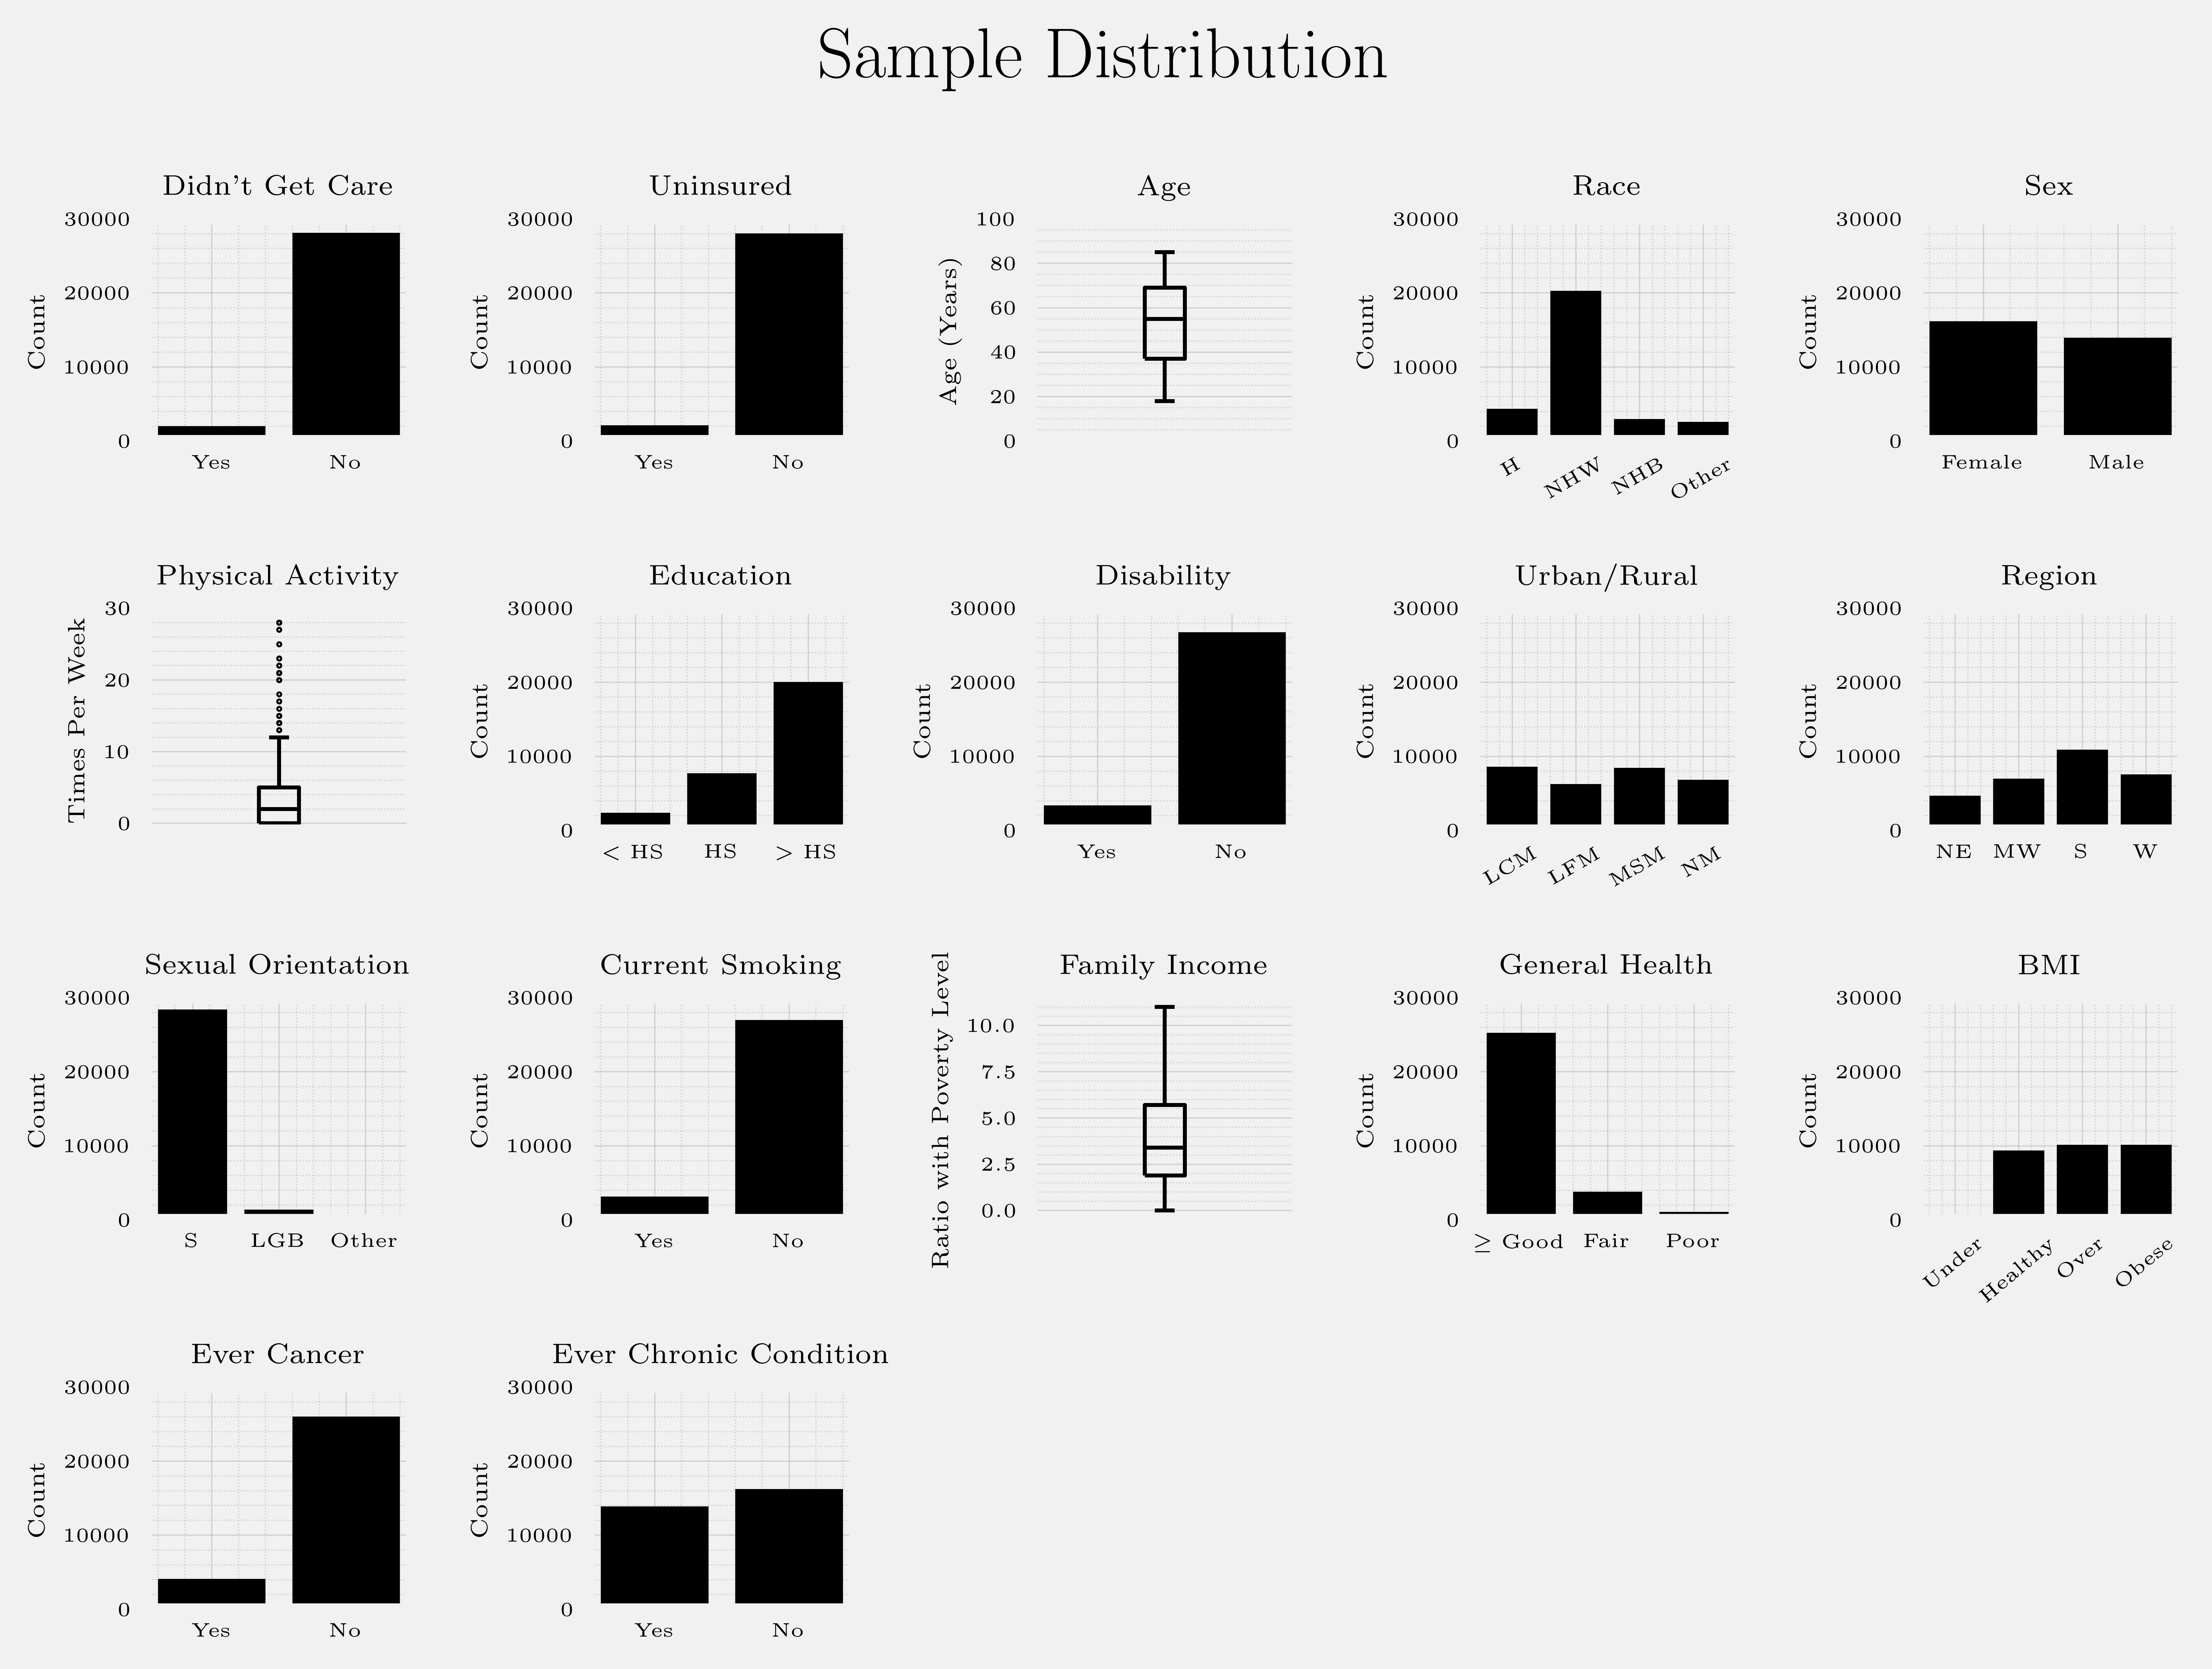

In [6]:
# create matplotlib figure object
fig = plt.figure(dpi = 1000, figsize = (8, 6))
mng = plt.get_current_fig_manager()
# use fancy LaTeX font
matplotlib.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 5})
# add title
fig.suptitle(r'$\textrm{Sample Distribution}$', fontsize = 18)

# plot feature distributions

ax = fig.add_subplot(451) # creates axes for plotting
ax.set_title(r"$\textrm{Didn't Get Care}$") # axis title
# bar plot
ax.bar([1, 2], [data['BinaryCare'].value_counts().get(1.0, 0), data['BinaryCare'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(452) # creates axes for plotting
ax.set_title(r"$\textrm{Uninsured}$") # axis title
# bar plot
ax.bar([1, 2], [data['NotInsured'].value_counts().get(1.0, 0), data['NotInsured'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(453) # creates axes for plotting
ax.set_title(r"$\textrm{Age}$") # axis title
# box plot
ax.boxplot(data['Age'], medianprops = dict(color = 'black'))
ax.set_ylabel(r'$\textrm{Age (Years)}$') # y label
plt.ylim(0, 100) # y-axis limits
ax.set_xticks([]) # x-axis ticks
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(454) # creates axes for plotting
ax.set_title(r"$\textrm{Race}$") # axis title
# bar plot
ax.bar([1, 2, 3, 4],
       [data['Race'].value_counts().get(1.0, 0),
        data['Race'].value_counts().get(2.0, 0),
        data['Race'].value_counts().get(3.0, 0),
        data['Race'].value_counts().get(4.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3, 4], [r'$\textrm{H}$', 
                             r'$\textrm{NHW}$', 
                             r'$\textrm{NHB}$', 
                             r'$\textrm{Other}$'], rotation = 30) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(455) # creates axes for plotting
ax.set_title(r"$\textrm{Sex}$") # axis title
# bar plot
ax.bar([1, 2], [data['Sex'].value_counts().get(1.0, 0), data['Sex'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Female}$', r'$\textrm{Male}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(456) # creates axes for plotting
ax.set_title(r"$\textrm{Physical Activity}$") # axis title
# box plot
ax.boxplot(data['PhysicalActivity'], 
           medianprops = dict(color = 'black'),
           flierprops = dict(marker = '.', markersize = 1))
ax.set_ylabel(r'$\textrm{Times Per Week}$') # y label
plt.ylim(-1, 30) # y-axis limits
ax.set_xticks([]) # x-axis ticks
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(457) # creates axes for plotting
ax.set_title(r"$\textrm{Education}$") # axis title
# bar plot
ax.bar([1, 2, 3], 
       [data['Education'].value_counts().get(1.0, 0),
        data['Education'].value_counts().get(2.0, 0),
        data['Education'].value_counts().get(3.0, 0)],
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3], [r'$<\textrm{HS}$', 
                          r'$\textrm{HS}$', 
                          r'$>\textrm{HS}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(458) # creates axes for plotting
ax.set_title(r"$\textrm{Disability}$") # axis title
# bar plot
ax.bar([1, 2], [data['Disability'].value_counts().get(1.0, 0), data['Disability'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(459) # creates axes for plotting
ax.set_title(r"$\textrm{Urban/Rural}$") # axis title
# bar plot
ax.bar([1, 2, 3, 4], 
       [data['UrbanRural'].value_counts().get(1.0, 0),
        data['UrbanRural'].value_counts().get(2.0, 0),
        data['UrbanRural'].value_counts().get(3.0, 0),
        data['UrbanRural'].value_counts().get(4.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3, 4], [r'$\textrm{LCM}$', 
                             r'$\textrm{LFM}$', 
                             r'$\textrm{MSM}$', 
                             r'$\textrm{NM}$'], rotation = 30) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 10) # creates axes for plotting
ax.set_title(r"$\textrm{Region}$") # axis title
# bar plot
ax.bar([1, 2, 3, 4], 
       [data['Region'].value_counts().get(1.0, 0),
        data['Region'].value_counts().get(2.0, 0),
        data['Region'].value_counts().get(3.0, 0),
        data['Region'].value_counts().get(4.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3, 4], [r'$\textrm{NE}$', 
                             r'$\textrm{MW}$', 
                             r'$\textrm{S}$', 
                             r'$\textrm{W}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 11) # creates axes for plotting
ax.set_title(r"$\textrm{Sexual Orientation}$") # axis title
# bar plot
ax.bar([1, 2, 3], 
       [data['SexualOrientation'].value_counts().get(1.0, 0),
        data['SexualOrientation'].value_counts().get(2.0, 0),
        data['SexualOrientation'].value_counts().get(3.0, 0)],
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3], [r'$\textrm{S}$', 
                          r'$\textrm{LGB}$', 
                          r'$\textrm{Other}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 12) # creates axes for plotting
ax.set_title(r"$\textrm{Current Smoking}$") # axis title
# bar plot
ax.bar([1, 2], [data['CurrentSmoking'].value_counts().get(1.0, 0), data['CurrentSmoking'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 13) # creates axes for plotting
ax.set_title(r"$\textrm{Family Income}$") # axis title
# box plot
ax.boxplot(data['FamilyIncome'],
           medianprops = dict(color = 'black'),
           flierprops = dict(marker = '.', markersize = 1))
ax.set_ylabel(r'$\textrm{Ratio with Poverty Level}$') # y label
plt.ylim(-0.5, 11.5) # y-axis limits
ax.set_xticks([]) # x-axis ticks
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 14) # creates axes for plotting
ax.set_title(r"$\textrm{General Health}$") # axis title
# bar plot
ax.bar([1, 2, 3], 
       [data['GeneralHealth'].value_counts().get(1.0, 0),
        data['GeneralHealth'].value_counts().get(2.0, 0),
        data['GeneralHealth'].value_counts().get(3.0, 0)],
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3], [r'$\geq\textrm{Good}$', 
                          r'$\textrm{Fair}$', 
                          r'$\textrm{Poor}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 15) # creates axes for plotting
ax.set_title(r"$\textrm{BMI}$") # axis title
# bar plot
ax.bar([1, 2, 3, 4], 
       [data['BMI'].value_counts().get(1.0, 0),
        data['BMI'].value_counts().get(2.0, 0),
        data['BMI'].value_counts().get(3.0, 0),
        data['BMI'].value_counts().get(4.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2, 3, 4], [r'$\textrm{Under}$', 
                             r'$\textrm{Healthy}$', 
                             r'$\textrm{Over}$', 
                             r'$\textrm{Obese}$'], rotation = 40) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 16) # creates axes for plotting
ax.set_title(r"$\textrm{Ever Cancer}$") # axis title
# bar plot
ax.bar([1, 2], [data['Cancer'].value_counts().get(1.0, 0), data['Cancer'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

ax = fig.add_subplot(4, 5, 17) # creates axes for plotting
ax.set_title(r"$\textrm{Ever Chronic Condition}$") # axis title
# bar plot
ax.bar([1, 2], [data['Chronic'].value_counts().get(1.0, 0), data['Chronic'].value_counts().get(0.0, 0)], 
       width=0.8, align='center', color = 'black')
ax.set_ylabel(r'$\textrm{Count}$') # y label
ax.set_xticks([1, 2], [r'$\textrm{Yes}$', r'$\textrm{No}$'], rotation = 0) # x-axis ticks
plt.ylim(0, 30000) # y-axis limits
ax.set_axisbelow(True) # axes beneath data
ax.minorticks_on() # add minor ticks between major ticks
ax.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), linestyle = '-', alpha = 0.5, linewidth = 0.3) # add major grid
ax.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), linestyle = ':', alpha = 0.5, linewidth = 0.3) # add minor grid

# ensures all text etcetera is within figure and with no overlap
fig.tight_layout(pad = 3)
# show figure
plt.show()

# One-Hot Encode Categorical Variables with >2 Categories and Format Data for Causal Modelling

In [7]:
# list of names of categorical features with >2 categories
predictorCols = ['Race', 'Education', 'UrbanRural', 'Region', 'SexualOrientation', 'GeneralHealth', 'BMI']
# one-hot encode these categorical features
encoder = OneHotEncoder(sparse_output = False, drop = 'first').set_output(transform = 'pandas')
encodedPredictorCols = encoder.fit_transform(data[predictorCols])
data = data.assign(**encodedPredictorCols)
# drop original (non-encoded) variables
data = data.drop(['Race', 'Education', 'UrbanRural', 'Region', 'SexualOrientation', 'GeneralHealth', 'BMI'], axis = 1)

# format data for causal model
treatment = data[['NotInsured']].values.reshape(len(data[['NotInsured']]),)
confounders = data[['Age', 'Race_2', 'Race_3', 'Race_4', 'Sex', 'PhysicalActivity', 
                    'Education_2.0', 'Education_3.0', 'Disability', 
                    'UrbanRural_2', 'UrbanRural_3', 'UrbanRural_4',
                    'Region_2', 'Region_3', 'Region_4', 'SexualOrientation_2.0', 
                    'SexualOrientation_3.0', 'CurrentSmoking', 'FamilyIncome',
                    'GeneralHealth_2.0', 'GeneralHealth_3.0', 'BMI_2.0', 'BMI_3.0', 'BMI_4.0',
                    'Cancer', 'Chronic']].to_numpy()
Y = data['BinaryCare'].values.reshape(len(data[['BinaryCare']]),)
print(treatment.shape)
print(confounders.shape)
print(Y.shape)

# inspect data
#data.head(3)

(30148,)
(30148, 26)
(30148,)


# Estimate Propensity Scores

In [7]:
# create propensity score model
propensityModel = ElasticNetPropensityModel(max_iter = 5000, # maximum number of iterations
                                            random_state = 1) # random number seed for reproducibility
# fit propensity model to data
propensityScores = propensityModel.fit_predict(confounders, Y)
# add to list of confounders
confounders = np.append(confounders, propensityScores.reshape(-1, 1), axis = 1)
# add to dataframe
data['propScore'] = propensityScores.reshape(-1, 1)

# Fit Causal Model and Estimate Average Treatment Effect

In [8]:
# create causal model
sLearner = BaseSClassifier(XGBClassifier(random_state = 1, # random number seed for reproducibility
                                         n_jobs = -1)) # use all CPU threads
# fit model to data and calculate ATE and confidence interval
ate, lower, upper = sLearner.estimate_ate(confounders, treatment, Y, return_ci = True)
# print ATE and confidence interval
print('Average Treatment Effect:', np.round(ate[0], 3), 
      'Confidence Interval:', np.round(lower[0], 3), '–', np.round(upper[0], 3))

Average Treatment Effect: 0.124 Confidence Interval: 0.111 – 0.137


# Sensitivity Tests

In [9]:
# create sensitivity testing object
sSense = Sensitivity(df = data, 
                     inference_features = ['Age', 'Race_2', 'Race_3', 'Race_4', 'Sex', 'PhysicalActivity', 
                                           'Education_2.0', 'Education_3.0', 'Disability', 
                                           'UrbanRural_2', 'UrbanRural_3', 'UrbanRural_4',
                                           'Region_2', 'Region_3', 'Region_4', 'SexualOrientation_2.0', 
                                           'SexualOrientation_3.0', 'CurrentSmoking', 'FamilyIncome',
                                           'GeneralHealth_2.0', 'GeneralHealth_3.0', 'BMI_2.0', 'BMI_3.0', 'BMI_4.0',
                                           'Cancer', 'Chronic', 'propScore'],
                     p_col = 'propScore',
                     treatment_col = 'NotInsured',
                     outcome_col = 'BinaryCare',
                     learner = sLearner)
# perform sensitivity tests
sSenseSummary = sSense.sensitivity_analysis(methods=['Placebo Treatment',
                                                     'Random Cause',
                                                     'Subset Data',
                                                     'Random Replace',
                                                     'Selection Bias'], sample_size = 0.5)
# display sensitivity test results
sSenseSummary.head(10)

,Method,ATE,New ATE,New ATE LB,New ATE UB
0,Placebo Treatment,0.123694,-0.002046,-0.006531,0.002439
1,Random Cause,0.123694,0.114157,0.101415,0.126900
2,Subset Data(sample size @0.5),0.123694,0.132398,0.117389,0.147408
3,Random Replace,0.123694,0.116296,0.103903,0.128690
4,"Selection Bias (alpha@0.0, with r-sqaure:0.0",0.123694,0.123694,0.110584,0.136803


# Plot Treatment Effect Distribution

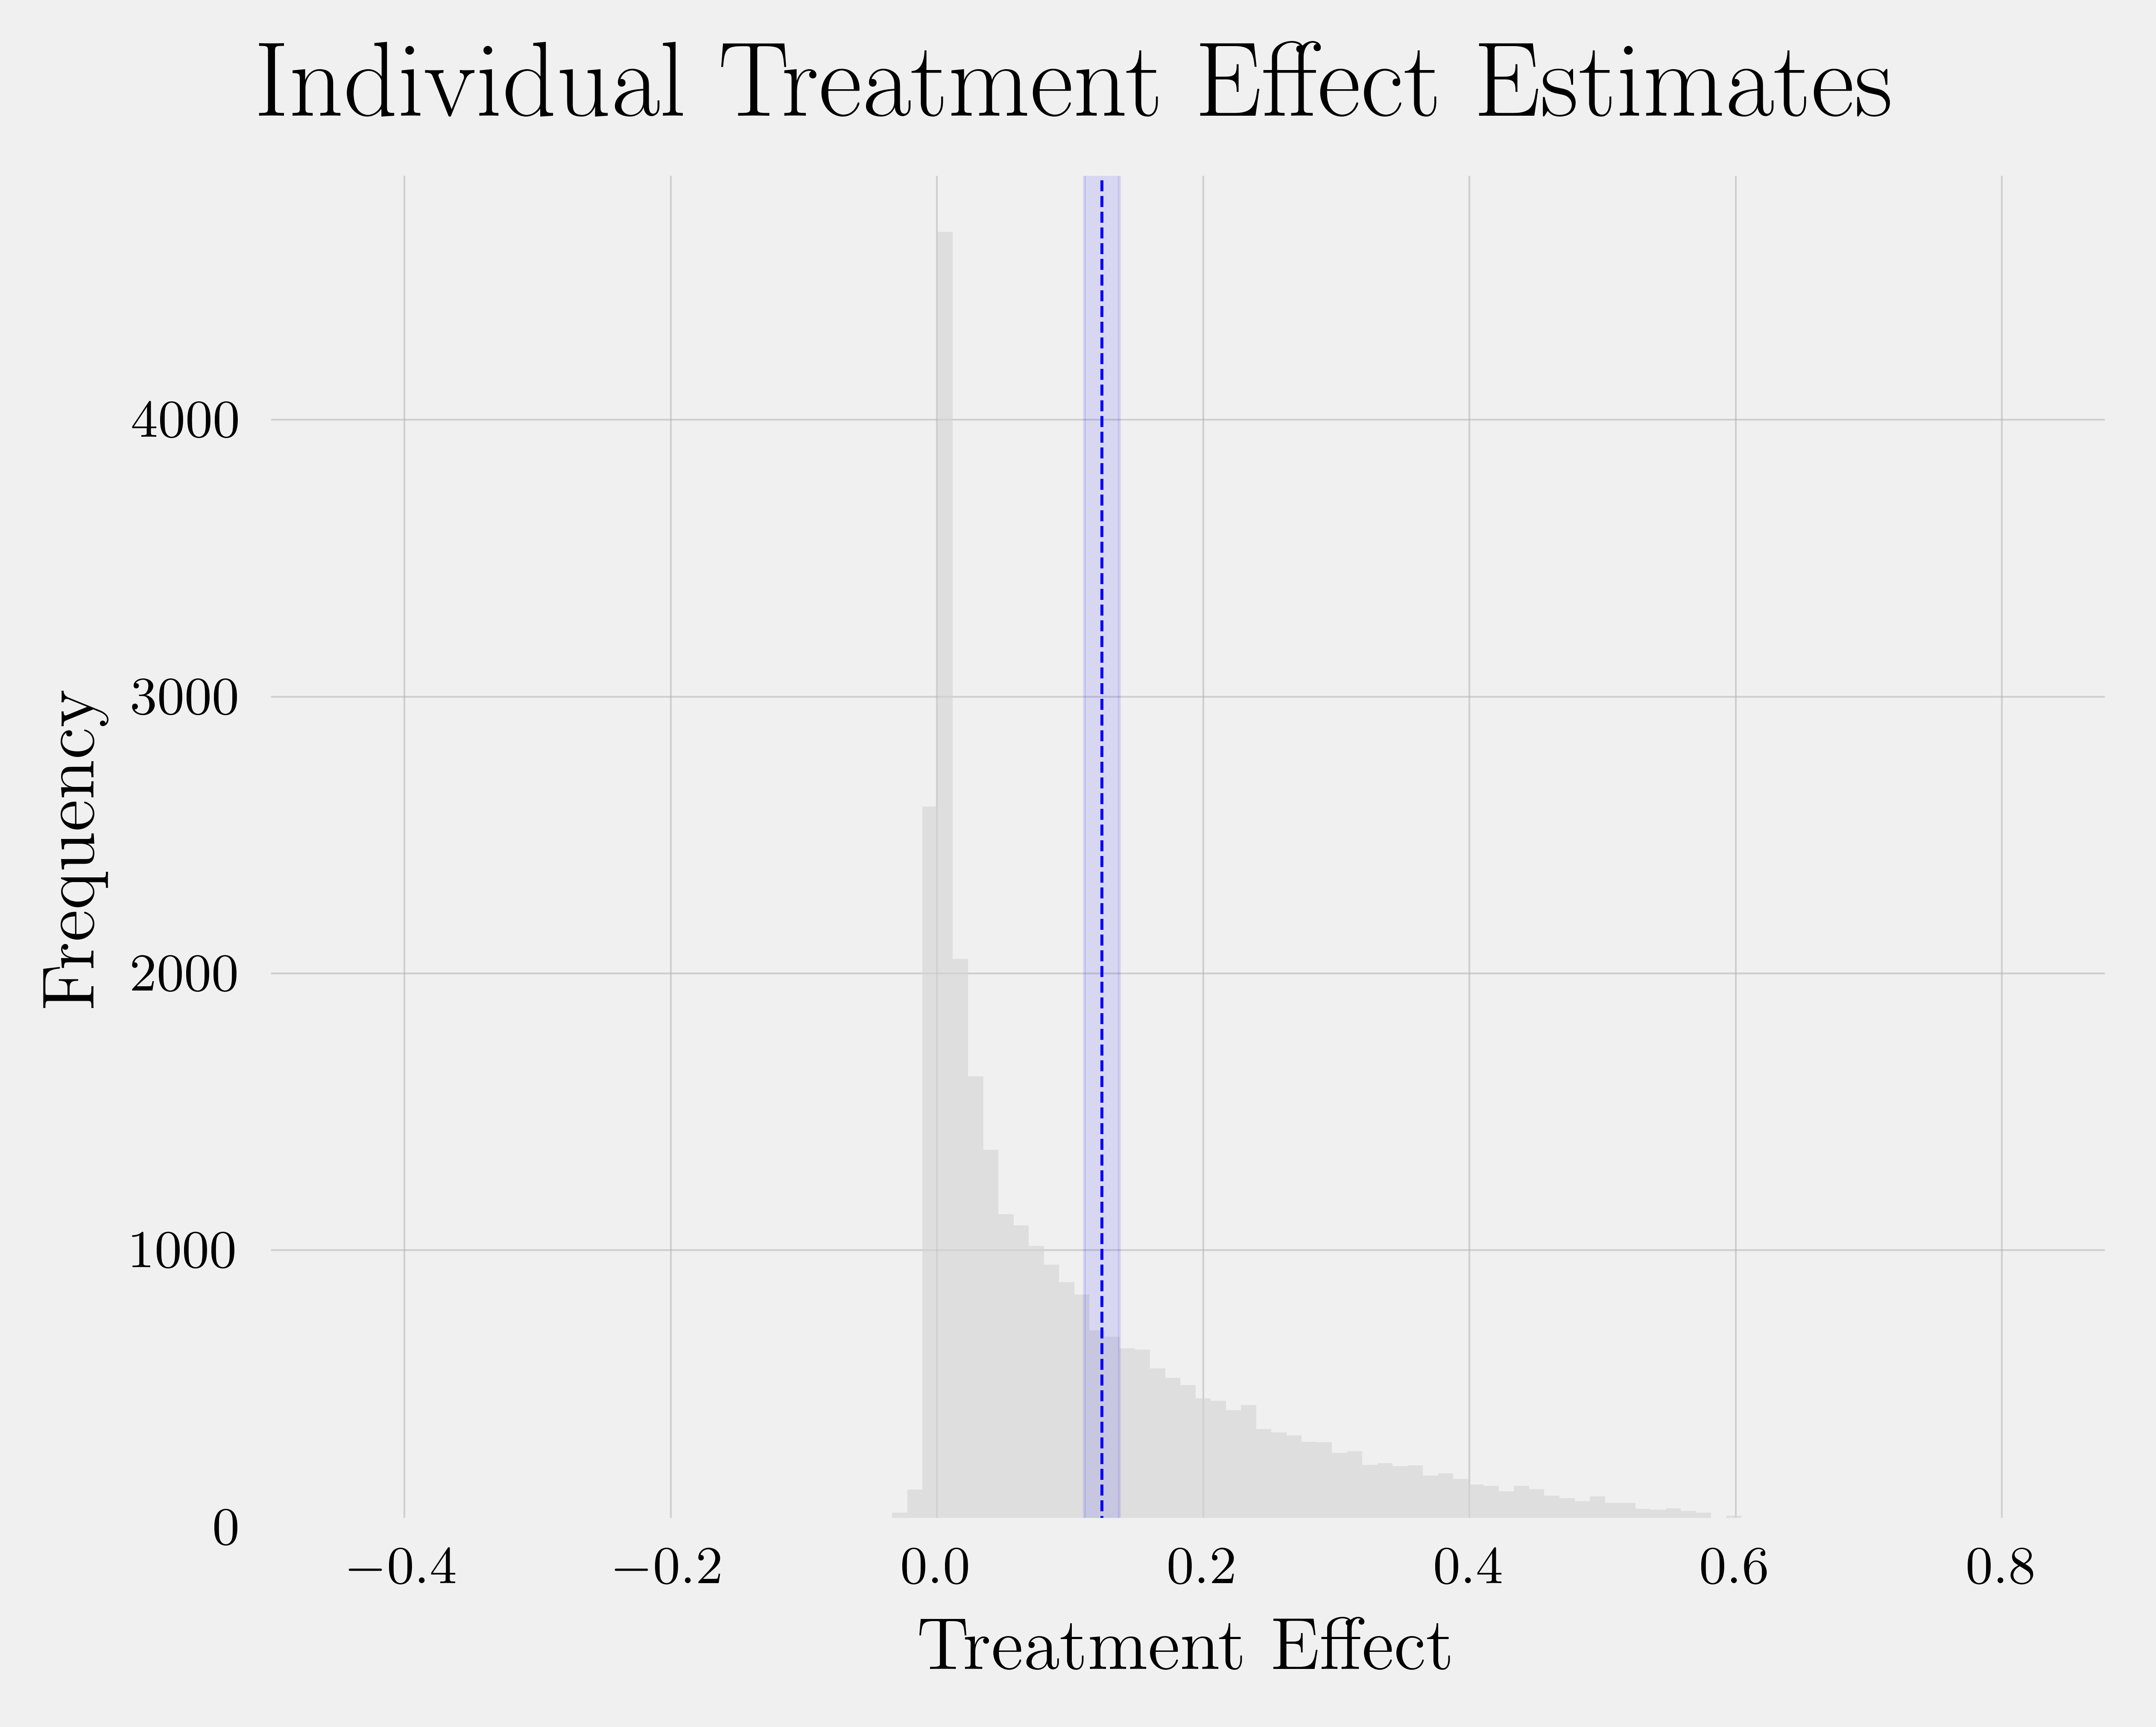

In [10]:
# create matplotlib figure object
fig = plt.figure(dpi = 1000, figsize = (5, 4))
mng = plt.get_current_fig_manager()
# use fancy LaTeX font
matplotlib.rcParams['text.usetex'] = True
# add title
fig.suptitle(r'$\textrm{Individual Treatment Effect Estimates}$', fontsize = 18)
# create plot axes
ax = plt.subplot(1, 1, 1)

# use model to predict individual treatment effects
preds = sLearner.fit_predict(confounders, treatment, Y)
preds = np.reshape(preds, -1)

# Freedman-Diaconis rule for bin count
iqr = np.quantile(preds, 0.75) - np.quantile(preds, 0.25)
binWidth = (2 * iqr) / (len(preds) ** (1 / 3))
binCount = int(np.ceil((np.max(preds) - np.min(preds)) / binWidth))

# plot histogram
plt.hist(preds, bins = binCount, alpha = 0.6, color = 'lightgray', density = False)
# plot ATE and confidence interval
plt.axvline(x = ate[0], color = 'blue', linestyle = '--', linewidth = 0.5)
ax.axvspan(lower[0], upper[0], alpha = 0.1, color = 'blue')
# add axis labels
plt.ylabel(r'$\textrm{Frequency}$', fontsize = 12.5)
plt.xlabel(r'$\textrm{Treatment Effect}$', fontsize = 12.5)
# change axis ticks fontsize
ax.tick_params(axis = 'both', which = 'major', labelsize = 9)
ax.set_axisbelow(True)
# add background grid
plt.grid(visible = True, which = 'major', color = (0.69, 0.69, 0.69), \
         linestyle = '-', alpha = 0.5, linewidth = 0.3)
plt.grid(visible = True, which = 'minor', color = (0.69, 0.69, 0.69), \
         linestyle = ':', alpha = 0.5, linewidth = 0.3)

# ensure all text etcetera is within plot
fig.tight_layout()
# show plot
plt.show()